> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

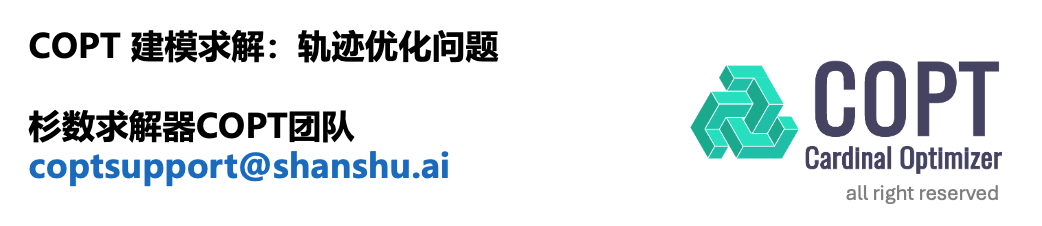

# 轨迹优化问题代码实现
## 使用COPT建模求解轨迹优化问题的步骤

1. 导入COPT-Python接口库 `coptpy`

2. 添加/导入模型**数据**

3. 创建**COPT求解环境**和**COPT求解模型**

4. 构建模型，依次添加**模型三要素**
- 添加**决策变量**：通过矩阵建模方式高效添加矩阵变量 ``MVar`` 
- 设置**目标函数**：构造矩阵 $\boldsymbol{Q}$ ，添加标准二次项 $\mathbf{p}^{\top} \boldsymbol{Q} \mathbf{p}$
- 添加**约束条件**：构造矩阵 $\boldsymbol{A}$ 和向量 $\mathbf{b}$ ，添加线性约束；离散化时间和障碍物区域后，添加 **Indicator** 约束

5. **求解**

6. 查看、分析**结果**

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT
import numpy as np
import math
from math import factorial

## 添加模型数据
在本案例中，我们选取 **$9$ 阶多项式**作为运动轨迹方程，选取最小化轨迹的 **jerk 能量**作为优化目标来决策出一组满足边界条件的最优系数组合。 $9$ 阶多项式有 $10$ 项的系数需要优化，变量共 $10$ 个，线性独立的运动条件有 $6$ 个，自由度为 $10-6=4$ 。在考虑实际问题时，我们需要选取合适阶数的多项式来优化运动轨迹，需要自由度 $\geq 1$，自由度为 $0$ 时，多项式系数有唯一解，无优化的空间。

对于系统的运动时间 $T$ 及系统的终点位置 $x=a$ ，我们设置 $T = 3.0\ s$ 和 $a = 5.0\ m$。

In [6]:
# 参数设置
T = 3.0 # 单位：s
a = 5.0 # 单位：m
n = 9  # 轨迹多项式阶数
r = 3  # 计算轨迹的 jerk 能量需要 3 阶导数

## 创建模型
创建名为`trajectory_opt_1`的模型`model_1`

In [9]:
env = cp.Envr()
model_1 = env.createModel("trajectory_opt_1")

Cardinal Optimizer v7.2.11. Build date Aug  1 2025
Copyright Cardinal Operations 2025. All Rights Reserved



## 添加模型三要素
### 添加决策变量
添加决策变量 $\mathbf{p}$ ，其中 $p_i \in [-10,\ 10],\ i = 0,\ 1,\ \dots,\ n$ ，是长度为9的向量（矩阵变量）。

In [11]:
# 添加变量 p0, p1, ..., p9 为一维矩阵变量，表示待优化的 9 阶多项式轨迹系数
p = model_1.addMVar(shape=n+1, lb=-10, ub=10, nameprefix="p")

### 设置目标函数
目标函数为
$$
\min_{\mathbf{p}}\; \ \mathbf{p}^{\top} \boldsymbol{Q} \mathbf{p}
$$
其中，最小化轨迹多项式 jerk 能量时构造出的 $\boldsymbol{Q}$ 为
$$
\boldsymbol{Q} =
\int_{0}^{1} \boldsymbol{\phi}^{(3)}(t^*)\boldsymbol{\phi}^{(3)}(t^*)^{\top} \, dt^* =
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 &  & \dots &  & 0 \\
0 & 0 & 0 & 0 & 0 &  & \dots &  & 0 \\
0 & 0 & 0 & 0 & 0 &  & \dots &  & 0 \\
0 & 0 & 0 & 36 & 72 & & \dots & & 6n(n-1) \\
0 & 0 & 0 & 72 & 192 & & \dots & & 24n(n-2) \\
& \vdots & & \vdots & \vdots & & \dots & & \vdots \\
0 & 0 & 0 & 6n(n-1) & 24n(n-2) & & \dots & & \frac{n^2(n-1)^2(n-2)^2}{(2n-5)}\\
\end{bmatrix}
$$

In [13]:
# 构造矩阵 Q 的工具函数
def construct_Q(n: int, r: int)-> np.ndarray:
    """
    矩阵元素公式 i,j ∈ {0,...,n}：
        若 i<r 或 j<r，则 Q[i,j] = 0
        若 i>=r 且 j>=r，则
            Q[i,j] = (i!/(i-r)!) * (j!/(j-r)!) / (i + j - 2r + 1)
    input:
    n : 多项式阶数 (n >= 0)
    r : 求导阶数 (0 <= r <= n)
    return:
    Q : (n+1)×(n+1) 的对称半正定矩阵 (numpy.ndarray)
    """
    if r < 0 or r > n:
        raise ValueError("要求导阶数 r 需满足 0 <= r <= n")

    Q = np.zeros((n + 1, n + 1), dtype=float)

    # 预计算阶乘和下降阶乘系数 c[i] = i! / (i-r)!
    fact = [factorial(k) for k in range(n + 1)]
    c = np.zeros(n + 1, dtype=float)
    for i in range(r, n + 1):
        c[i] = fact[i] / fact[i - r]

    # 填充元素
    for i in range(r, n + 1):
        for j in range(r, n + 1):
            Q[i, j] = c[i] * c[j] / (i + j - 2 * r + 1)

    return Q

我们通过上述方法构造二次目标函数中的矩阵 $\boldsymbol{Q}$ ，并通过矩阵建模的方式构建表达式 $\mathbf{p}^{\top} \boldsymbol{Q} \mathbf{p}$ ：

In [15]:
# 添加目标函数，最小化 9 阶多项式的 jerk 能量
Q = construct_Q(n, r)
model_1.setObjective(p @ Q @ p, sense=COPT.MINIMIZE)

### 添加约束条件
将初始及终点的位置、速度、加速度要求整合为线性约束，并用矩阵表示：
$$
\text{s.t.}\;
\begin{cases}
x^*(0) = 0,\ x^*(1) = 1 \quad (归一化位置) \\
x^{*(1)}(0) = 0,\ x^{*(1)}(1) = 0 \quad (归一化速度) \\
x^{*(2)}(0) = 0,\ x^{*(2)}(1) = 0 \quad (归一化加速度)
\end{cases}
\quad \Longleftrightarrow \quad
\text{s.t.}\; \boldsymbol{A} \mathbf{p} = \mathbf{b}
$$
其中，
$$
\boldsymbol{A} =
\begin{bmatrix}
\boldsymbol{\phi}(0)^{\top} \\
\boldsymbol{\phi}^{(1)}(0)^{\top} \\
\boldsymbol{\phi}^{(2)}(0)^{\top} \\
\boldsymbol{\phi}(1)^{\top} \\
\boldsymbol{\phi}^{(1)}(1)^{\top} \\
\boldsymbol{\phi}^{(2)}(1)^{\top}
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & \dots & 0 \\
0 & 1 & 0 & \dots & 0 \\
0 & 0 & 2 & \dots & 0 \\
1 & 1 & 1 & \dots & 1 \\
0 & 1 & 2 & \dots & n \\
0 & 0 & 2 & \dots & n(n-1) \\
\end{bmatrix}
\quad \quad \quad
\mathbf{b} =
\begin{bmatrix}
0 \\
0 \\
0 \\
1 \\
0 \\
0
\end{bmatrix}
$$

In [17]:
# 计算 n 阶多项式 Φ(t*) 基函数向量的 r 阶导数在 t* 处的函数值向量
def phi_derivative_value(n: int, r: int, t) -> np.ndarray:
    """
    计算 n 阶多项式基函数 φ(t*) = [1, t*, t*^2, ..., t*^n]^T 的 r 阶导数
    在 t* 处的函数值向量 φ^{(r)}(t*)。

    向量元素公式 i ∈ {0,...,n}：
        i < r:        φ^{(r)}_i(t*) = 0
        i >= r:       φ^{(r)}_i(t*) = i!/(i-r)! * t*^{i-r}

    input:
    - n  : 多项式阶数（n >= 0）
    - r  : 求导阶数（0 <= r <= n）
    - t* : 时刻，可为标量或一维 numpy 数组

    返回
    ----
    若 t 为标量，返回形状 (n+1,) 的向量；
    若 t 为数组，返回形状 (len(t), n+1) 的矩阵（每行对应一个 t_k）。
    """
    if r < 0 or r > n:
        raise ValueError("r 必须满足 0 <= r <= n")

    t_arr = np.asarray(t, dtype=float)
    scalar_input = (t_arr.ndim == 0)
    if scalar_input:
        t_arr = t_arr.reshape(1)

    m = t_arr.size
    out = np.zeros((m, n + 1), dtype=float)

    # 预计算下降阶乘系数 c[i] = i!/(i-r)!
    fact = [factorial(k) for k in range(n + 1)]
    c = np.zeros(n + 1, dtype=float)
    for i in range(r, n + 1):
        c[i] = fact[i] / fact[i - r]

    # 填充 φ^{(r)}(t) 分量
    for i in range(r, n + 1):
        out[:, i] = c[i] * (t_arr ** (i - r))

    return out[0] if scalar_input else out

# 构造矩阵 A 和向量 b
A = np.array([
    phi_derivative_value(n, 0, 0),
    phi_derivative_value(n, 1, 0),
    phi_derivative_value(n, 2, 0),
    phi_derivative_value(n, 0, 1),
    phi_derivative_value(n, 1, 1),
    phi_derivative_value(n, 2, 1),
], dtype=float)

b = np.array([0, 0, 0, 1, 0, 0], dtype=float)

# 添加约束
model_1.addConstrs(A@p == b, nameprefix="")

MConstr(shape=(6,), data=
[<coptpy.Constraint: (0)> <coptpy.Constraint: (1)>
 <coptpy.Constraint: (2)> <coptpy.Constraint: (3)>
 <coptpy.Constraint: (4)> <coptpy.Constraint: (5)>])

## 求解

In [19]:
model_1.solve()

Model fingerprint: afaae091

Using Cardinal Optimizer v7.2.11 on macOS (aarch64)
Hardware has 10 cores and 10 threads. Using instruction set ARMV8 (30)
Minimizing a QP problem

The original problem has:
    6 rows, 10 columns and 30 non-zero elements
    28 quadratic objective elements
The presolved problem has:
    10 rows, 14 columns and 56 non-zero elements
    7 quadratic objective elements

Starting barrier solver using 10 CPU threads

Problem info:
Dualized in presolve:            No
Range of matrix coefficients:    [2e-01,9e+01]
Range of rhs coefficients:       [1e+00,1e+00]
Range of bound coefficients:     [1e+01,1e+01]
Range of cost coefficients:      [0e+00,0e+00]
Range of quadcost coefficients:  [1e+00,1e+00]

Factor info:
Number of free columns:          7
Number of dense columns:         0
Number of matrix entries:        5.500e+01
Number of factor entries:        5.500e+01
Number of factor flops:          3.850e+02

Iter       Primal.Obj         Dual.Obj      Compl  Prima

## 获取结果

求得最优解后，我们可以获取最小的jerk能量值，以及对应最优平滑轨迹运动方程的参数。

In [21]:
# 输出结果
if model_1.status == COPT.OPTIMAL:
    print("Optimal jerk(non-dimension):", model_1.objval)
    print("Coefficients:")
    p_results = np.array(p.X.tolist())    # matplotlib cannot consume coptpy's NdArray
    for i, item in enumerate(p_results):
        print(" p({0}) = {1:.3f}".format(i, item))
else:
    print("Solve failed with status:", model_1.status)

Optimal jerk(non-dimension): 721.316347526782
Coefficients:
 p(0) = 0.000
 p(1) = 0.000
 p(2) = 0.000
 p(3) = 9.072
 p(4) = -10.000
 p(5) = -4.435
 p(6) = 10.000
 p(7) = -3.465
 p(8) = -0.761
 p(9) = 0.589


进一步，我们可以得到各时刻的运动轨迹的位置、速度、加速度，并绘制出轨迹图像。

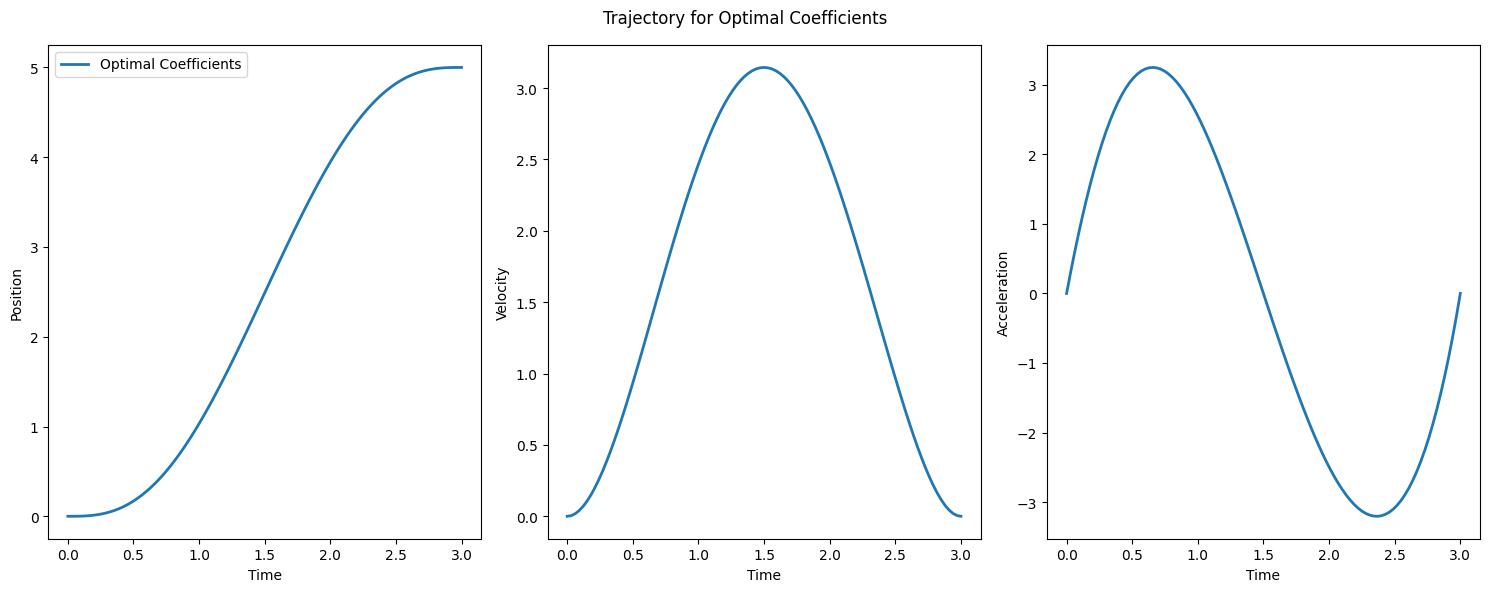

In [23]:
# 计算各时刻的位置、速度、加速度
time_grid_star = np.linspace(0.0, 1.0, 100+1)
position_1D_star = phi_derivative_value(n, 0, time_grid_star) @ p_results
velocity_1D_star = phi_derivative_value(n, 1, time_grid_star) @ p_results
acceleration_1D_star = phi_derivative_value(n, 2, time_grid_star) @ p_results

# 恢复物理量纲
time_grid = time_grid_star * T
position_1D = a * position_1D_star
velocity_1D = (a / T) * velocity_1D_star
acceleration_1D = (a / T**2) * acceleration_1D_star


# 绘制轨迹图像
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.plot(time_grid, position_1D, linewidth=2, label="Optimal Coefficients")
plt.xlabel("Time")
plt.ylabel("Position")
plt.legend()


plt.subplot(1, 3, 2)
plt.plot(time_grid, velocity_1D, linewidth=2, label="Optimal Coefficients")
plt.xlabel("Time")
plt.ylabel("Velocity")


plt.subplot(1, 3, 3)
plt.plot(time_grid, acceleration_1D, linewidth=2, label="Optimal Coefficients")
plt.xlabel("Time")
plt.ylabel("Acceleration")


plt.suptitle("Trajectory for Optimal Coefficients")
plt.tight_layout()
plt.show()

# 案例拓展：考虑避障的轨迹优化问题代码实现

## 添加模型数据

In [26]:
n = 9  # 轨迹多项式阶数
r = 3  # 计算轨迹的 jerk 能量需要 3 阶导数
T = 2.0 # 单位：s
x_obs = np.array([1.0, 0.8])
R_safe = 0.3
# 初始状态
x_0 = np.array([0.0, 0.0])
v_0 = np.array([1.0, 1.0])
a_0 = np.array([0.0, 0.0])
# 终点状态
x_T = np.array([2.0, 1.5])
v_T = np.array([0.0, 0.0])
a_T = np.array([0.0, 0.0])
# 离散化计算
K = 40
L = 20

### 数据归一化处理

In [28]:
# 障碍物中心
x_obs_star = (x_obs - x_0) / (x_T - x_0)

# 归一化椭圆半径：R*_x、R*_y
R_star = R_safe / (x_T - x_0)

# 离散化时间与角度
t_star = {k: k / K for k in range(K + 1)} # 归一化处理
theta  = {l: 2 * np.pi * l / L for l in range(1, L + 1)}

# 单位法向量
n_hat = {l: np.array([np.cos(theta[l]), np.sin(theta[l])], dtype=float)
         for l in range(1, L + 1)}

# 截距
d_star = {l: n_hat[l] @ x_obs_star + np.linalg.norm(R_star * n_hat[l])
          for l in range(1, L + 1)}

# 初始、终点状态
x_0_star = (x_0 - x_0) / (x_T - x_0)
v_0_star = T / (x_T - x_0) * v_0
a_0_star = T**2 / (x_T - x_0) * a_0
x_T_star = (x_T - x_0) / (x_T - x_0)
v_T_star = T / (x_T - x_0) * v_T
a_T_star = T**2 / (x_T - x_0) * a_T

## 创建模型
创建名为`trajectory_opt_2`的模型`model_2`

In [30]:
env = cp.Envr()
model_2 = env.createModel("trajectory_opt_2")

Cardinal Optimizer v7.2.11. Build date Aug  1 2025
Copyright Cardinal Operations 2025. All Rights Reserved



## 添加模型三要素

### 添加决策变量
添加决策变量 $\mathbf{p}_x$ 、$\mathbf{p}_y$ ，其中所有元素的取值范围均为 $[-10,\ 10]$ ；添加二元变量 $b_{k,\ell}$ 。

In [32]:
p_x = model_2.addMVar(shape=n+1, lb=-10, ub=10, nameprefix="p_x")
p_y = model_2.addMVar(shape=n+1, lb=-10, ub=10, nameprefix="p_y")
b_index = list((k, l) for k in range(K+1) for l in range(1, L+1))
b = model_2.addVars(b_index, vtype=COPT.BINARY, nameprefix="b")

### 设置目标函数
目标函数为
$$
\min_{\mathbf{p}_x,\ \mathbf{p}_y}\quad \mathbf{p}^{\top}_{x} \boldsymbol{Q} \mathbf{p}_{x} + \mathbf{p}^{\top}_{y} \boldsymbol{Q} \mathbf{p}_{y}
$$

In [34]:
Q = construct_Q(n, r)
model_2.setObjective(p_x @ Q @ p_x + p_y @ Q @ p_y, sense=COPT.MINIMIZE)

### 添加约束条件
添加初始和终点状态的线性约束。
$$
\boldsymbol{A} \mathbf{p}_x = \mathbf{b}_x
$$
$$
\boldsymbol{A} \mathbf{p}_y = \mathbf{b}_y
$$
$$
\mathbf{b}_x =
\begin{bmatrix}
x_0^* \\
v_{x,0}^* \\
a_{x,0}^* \\
x_T^* \\
v_{x,T}^* \\
a_{x,T}^*
\end{bmatrix}
\quad \quad \quad
\mathbf{b}_y =
\begin{bmatrix}
y_0^* \\
v_{y,0}^* \\
a_{y,0}^* \\
y_T^* \\
v_{y,T}^* \\
a_{y,T}^*
\end{bmatrix}
$$

In [36]:
b_x = np.array([x_0_star[0], v_0_star[0], a_0_star[0], x_T_star[0], v_T_star[0], a_T_star[0]])
b_y = np.array([x_0_star[1], v_0_star[1], a_0_star[1], x_T_star[1], v_T_star[1], a_T_star[1]])

在添加矩阵线性约束的时候，我们除了可以通过此前使用的 ``model_1.addConstrs(A@p == b, nameprefix="")`` 这种方式之外；还可以通过专门的类函数添加矩阵约束，定义函数参量的方式：

In [38]:
model_2.addMConstr(A=A, x=p_x, sense=COPT.EQUAL, b=b_x, nameprefix="x-direction-linear-constraint")
model_2.addMConstr(A=A, x=p_y, sense=COPT.EQUAL, b=b_y, nameprefix="y-direction-linear-constraint")

MConstr(shape=(6,), data=
[<coptpy.Constraint: y-direction-linear-constraint(0)>
 <coptpy.Constraint: y-direction-linear-constraint(1)>
 <coptpy.Constraint: y-direction-linear-constraint(2)>
 <coptpy.Constraint: y-direction-linear-constraint(3)>
 <coptpy.Constraint: y-direction-linear-constraint(4)>
 <coptpy.Constraint: y-direction-linear-constraint(5)>])

添加避障约束

$$
\begin{aligned}
\sum_{\ell = 1}^{L}\ b_{k,\ell} &\geq 1,\quad\quad\quad k = 0,\ 1,\ \cdots,K \\
\hat{\mathbf{n}}_{\ell}^{\top}\,\begin{bmatrix}
\boldsymbol{\phi}(t_k^*)^{\top} \mathbf{p}_x \\
\boldsymbol{\phi}(t_k^*)^{\top} \mathbf{p}_y \\
\end{bmatrix} &\geq d_{\ell}^*,\quad\quad\quad if \ \  b_{k,\ell} = 1
\end{aligned}
$$

<font color=#0000FF>
<b>提示：使用 COPT 添加 Indicator 约束</b>
</font>

Indicator 约束是一类 *If–Then* 逻辑关系约束：用一个二进制变量 $y$ 作为 indicator，根据 $y$ 的取值，决定线性约束是否生效：

$$
y = 1 \;\Rightarrow\; a^{\top}x \leq b
$$
$$
y \in \{0,\ 1\}
$$
含义：如果 $y=1$ ，则线性约束 $a^{\top}x \leq b$ 成立。

对于 *If–Then* 形式的条件约束，可使用 **COPT** 的 Indicator 构造器
`Model.addGenConstrIndicator(binvar, binval, lhs, sense=None, rhs=None, type=COPT.INDICATOR_IF, name="")` 添加，需指定参数：

- `binVar`：二进制变量，作为 indicator；
- `binval`：indicator 的取值，可取值为 `True` 或 `False` ，代表二进制变量取值为 $1$ 或 $0$ ；
- `lhs`：`binVar` 为 `True` 时需要成立的线性约束表达式。



In [70]:
for k in range(K+1):
    for l in range(1, L+1):
        phi_k = np.array(phi_derivative_value(n, 0, t_star[k]))
        x_k = phi_k @ p_x
        y_k = phi_k @ p_y
        expr = n_hat[l][0] * x_k + n_hat[l][1] * y_k
        model_2.addGenConstrIndicator(b[(k, l)], True, expr >= d_star[l])
    model_2.addConstr(cp.quicksum(b[(k, l)] for l in range(1, L+1)) >= 1)

## 求解

In [73]:
model_2.solve()
px_results = np.array(p_x.X.tolist())
py_results = np.array(p_y.X.tolist())

Model fingerprint: ad74e69f

Using Cardinal Optimizer v7.2.11 on macOS (aarch64)
Hardware has 10 cores and 10 threads. Using instruction set ARMV8 (30)
Minimizing a MIQP problem

The original problem has:
    53 rows, 840 columns and 880 non-zero elements
    820 binaries
    820 indicators
    56 quadratic objective elements

Starting the MIP solver with 10 threads and 32 tasks

Presolving the problem

The presolved problem has:
    488 rows, 479 columns and 4232 non-zero elements
    8 SOC rows and 24 non-zero elements
    451 binaries


     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  2.933333e+02            --     Inf  0.10s
         0         1      --      24  2.933333e+02            --     Inf  0.16s
         0         1      --      26  2.933333e+02            --     Inf  0.16s
         0         1      --      26  2.933333e+02            --     Inf  0.17s
         0         1      --      26  2.933333e+02    

## 获取结果

In [76]:
# 输出结果
if model_2.status == COPT.OPTIMAL:
    print("Optimal jerk(non-dimension):", model_2.objval)
    print("Coefficients:")
    px_results = np.array(p_x.X.tolist())
    py_results = np.array(p_y.X.tolist())
    for i, item in enumerate(px_results):
        print(" p_x({0}) = {1:.3f}".format(i, item))
    for i, item in enumerate(py_results):
        print(" p_y({0}) = {1:.3f}".format(i, item))
else:
    print("Solve failed with status:", model_2.status)

Optimal jerk(non-dimension): 965.5193568943433
Coefficients:
 p_x(0) = 0.000
 p_x(1) = 1.000
 p_x(2) = 0.000
 p_x(3) = -3.704
 p_x(4) = 10.000
 p_x(5) = -0.763
 p_x(6) = -10.000
 p_x(7) = -1.862
 p_x(8) = 10.000
 p_x(9) = -3.671
 p_y(0) = 0.000
 p_y(1) = 1.333
 p_y(2) = 0.000
 p_y(3) = 5.601
 p_y(4) = -10.000
 p_y(5) = -3.178
 p_y(6) = 10.000
 p_y(7) = 3.720
 p_y(8) = -10.000
 p_y(9) = 3.524


进一步，我们可以得到各时刻的运动轨迹的位置、速度、加速度，并绘制出考虑避障情况下的轨迹图像。

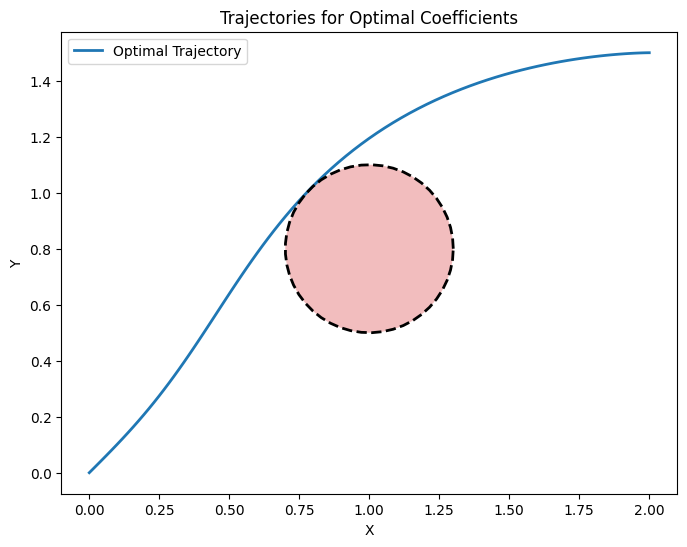

In [78]:
# 计算各时刻的位置、速度、加速度
time_grid_star = np.linspace(0.0, 1.0, 100+1)
position_2D_x_star = phi_derivative_value(n, 0, time_grid_star) @ px_results
position_2D_y_star = phi_derivative_value(n, 0, time_grid_star) @ py_results

# 恢复物理量纲
time_grid = time_grid_star * T
position_2D_x = position_2D_x_star * (x_T[0] - x_0[0]) + x_0[0]
position_2D_y = position_2D_y_star * (x_T[1] - x_0[1]) + x_0[1]

# 绘制出不可通过的圆形障碍区
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_obstacle(ax, center, radius,
                  facecolor="tab:red", edgecolor="k", alpha=0.3,
                  linestyle="--", linewidth=2):
    """
    绘制一个圆形障碍区，包含边界和填充阴影

    input:
    - ax        : matplotlib 的 Axes 对象
    - center    : (x, y) 圆心坐标
    - radius    : 圆的半径
    - facecolor : 阴影颜色
    - edgecolor : 边界颜色
    - alpha     : 阴影透明度
    - linestyle : 边界线型
    - linewidth : 边界线宽
    """
    x_obs, y_obs = center
    # 阴影
    circ = Circle(center, radius, facecolor=facecolor,
                  edgecolor=edgecolor, alpha=alpha, linewidth=0)
    ax.add_patch(circ)

    # 边界线
    theta = np.linspace(0, 2*np.pi, 50)
    ax.plot(x_obs + radius*np.cos(theta),
            y_obs + radius*np.sin(theta),
            color=edgecolor, linestyle=linestyle, linewidth=linewidth)

    return ax

# 绘制轨迹图像
fig, ax = plt.subplots(figsize=(8, 6))
# 绘制轨迹
ax.plot(position_2D_x, position_2D_y, linewidth=2, label="Optimal Trajectory")

# 添加障碍物
plot_obstacle(ax, center=x_obs, radius=R_safe)

ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Trajectories for Optimal Coefficients")
plt.show()